<a href="https://colab.research.google.com/github/M-Anees-Jafar1/Fruit-Detection-YOLOv8/blob/main/fruit_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive"

'2431-BISE Lahore 12th Class Result Gazette 2024 PDF-by-Admin-(taleem360.com).gdoc'
'archive (3)'
'archive (6)'
'archive (6).zip'
'can you solve question 5 to 20 of this page.gsheet'
 Classroom
'Colab Notebooks'
'Computer Science Short Notes Class 9th (1).pdf'
 email.csv
 fruit_yolo_results
'self.relu = nn.ReLU()'$'\n\n''        self.pool = nn.Max... (1).gsheet'
'self.relu = nn.ReLU()'$'\n\n''        self.pool = nn.Max....gsheet'
 waste_classifier_model.pth


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/archive (6).zip"
extract_path = "/content/fruit_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
!find /content/fruit_dataset -maxdepth 2 -type d


/content/fruit_dataset
/content/fruit_dataset/Fruits-detection
/content/fruit_dataset/Fruits-detection/train
/content/fruit_dataset/Fruits-detection/test
/content/fruit_dataset/Fruits-detection/valid


In [ ]:
!find /content/fruit_dataset -maxdepth 2 -type f | head -20

/content/fruit_dataset/Fruits-detection/data.yaml
/content/fruit_dataset/Fruits-detection/README.txt
/content/fruit_dataset/Fruits-detection/cli.log
/content/fruit_dataset/Fruits-detection/yolov8s.pt


In [ ]:
import os

dataset_path = "/content/fruit_dataset/Fruits-detection"

print("Train images:", len(os.listdir(f"{dataset_path}/train/images")))
print("Train labels:", len(os.listdir(f"{dataset_path}/train/labels")))

print("Valid images:", len(os.listdir(f"{dataset_path}/valid/images")))
print("Valid labels:", len(os.listdir(f"{dataset_path}/valid/labels")))

print("Test images:", len(os.listdir(f"{dataset_path}/test/images")))
print("Test labels:", len(os.listdir(f"{dataset_path}/test/labels")))

Train images: 7108
Train labels: 7108
Valid images: 914
Valid labels: 914
Test images: 457
Test labels: 457


In [ ]:
import yaml

data_yaml = f"{dataset_path}/data.yaml"

with open(data_yaml, "r") as f:
    data = yaml.safe_load(f)

print(data)

{'names': ['Apple', 'Banana', 'Grape', 'Orange', 'Pineapple', 'Watermelon'], 'nc': 6, 'test': 'E:\\DL\\attempt1\\attempt3\\datasets\\Fruits-detection-1\\test\\images', 'train': 'E:\\DL\\attempt1\\attempt3\\datasets\\Fruits-detection-1\\train\\images', 'val': 'E:\\DL\\attempt1\\attempt3\\datasets\\Fruits-detection-1\\valid\\images'}


In [ ]:
import yaml

dataset_path = "/content/fruit_dataset/Fruits-detection"

data = {
    "path": dataset_path,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": [
        "Apple",
        "Banana",
        "Grape",
        "Orange",
        "Pineapple",
        "Watermelon"
    ],
    "nc": 6
}

with open(f"{dataset_path}/data.yaml", "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("data.yaml updated successfully!")

data.yaml updated successfully!


In [ ]:
with open(f"{dataset_path}/data.yaml", "r") as f:
    print(f.read())

path: /content/fruit_dataset/Fruits-detection
train: train/images
val: valid/images
test: test/images
names:
- Apple
- Banana
- Grape
- Orange
- Pineapple
- Watermelon
nc: 6



Image: 4a65a5eb9af2aff3_jpg.rf.381688a631b4d488242f62f1ffc5faa3.jpg
Label: 4a65a5eb9af2aff3_jpg.rf.381688a631b4d488242f62f1ffc5faa3.txt


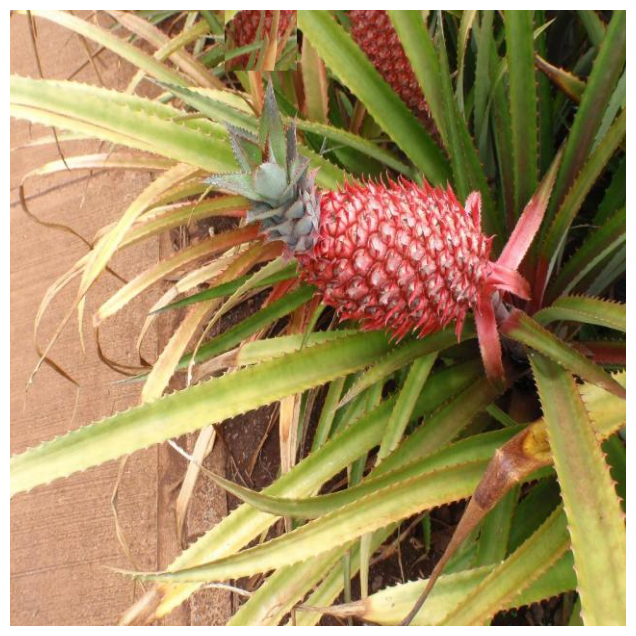


YOLO Labels:
4 0.5484375 0.32109375 0.48046875 0.44609375
4 0.40703125 0.04921875 0.1171875 0.0984375
4 0.6171875 0.0890625 0.15234375 0.17734375


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

dataset_path = "/content/fruit_dataset/Fruits-detection"

image_dir = f"{dataset_path}/train/images"
label_dir = f"{dataset_path}/train/labels"

# First image
image_name = os.listdir(image_dir)[0]

image_path = os.path.join(image_dir, image_name)

# Corresponding label
label_name = os.path.splitext(image_name)[0] + ".txt"
label_path = os.path.join(label_dir, label_name)

print("Image:", image_name)
print("Label:", label_name)

# Display image
image = Image.open(image_path)

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

# Display raw YOLO labels
with open(label_path, "r") as f:
    print("\nYOLO Labels:")
    print(f.read())

In [ ]:
from ultralytics import YOLO

print("Ultralytics imported successfully!")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics imported successfully!


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")

print("YOLO26s loaded successfully!")

YOLO26s loaded successfully!


In [ ]:
results = model.train(
    data="/content/fruit_dataset/Fruits-detection/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/fruit_training",
    name="fruit_yolo26s"
)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fruit_dataset/Fruits-detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fruit_yolo2

In [ ]:
import glob

weights = glob.glob(
    "/content/fruit_training/fruit_yolo26s/weights/*.pt"
)

print(weights)

['/content/fruit_training/fruit_yolo26s/weights/last.pt', '/content/fruit_training/fruit_yolo26s/weights/best.pt']


In [ ]:
import shutil

shutil.copy(
    "/content/fruit_training/fruit_yolo26s/weights/best.pt",
    "/content/drive/MyDrive/fruit_best.pt"
)

print("best.pt saved to Google Drive!")

best.pt saved to Google Drive!
